**Uploading the Zip File**

In [1]:
from google.colab import files

# Upload your zip file
uploaded = files.upload()

Saving yelp_processed.zip to yelp_processed.zip


**Unzip the File and Checking Contents**

In [2]:
import zipfile
import os

zip_file_name = "yelp_processed.zip"
extract_path = "/content/yelp_data"

# Unzip
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully.\n📂 Extracted folders and files:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}📁 {os.path.basename(root)}")
    for f in files:
        print(f"{indent}  📄 {f}")

Streaming output truncated to the last 5000 lines.
      📄 6dOyY2-sn8N2gzMqKrc5vA.jpg
      📄 Ffmz5_P_MI9VEwdPpKzDHw.jpg
      📄 aeYFCfly8A7V2yOXNCJI-Q.jpg
      📄 8Rebn-_1eiQjsGO6zcdQmg.jpg
      📄 7Upn4_EXitJkGeFRKJTchg.jpg
      📄 4BlYSQ8O9559bQ9uqfTqJQ.jpg
      📄 0FxFCJ__rr2k55JxIup5EQ.jpg
      📄 EVIV7x9LbtamhUvWsx73Gw.jpg
      📄 2RIf7lmEVm1vQLeUuuHj_A.jpg
      📄 AzrxH4OPeRwMHGhRPH3zUw.jpg
      📄 D6P902-V4KvLiqQCrHPiMg.jpg
      📄 aAvBXeffkiVCdfMXGZTPqA.jpg
      📄 cQn4DxVblJkP3iF87TX0yw.jpg
      📄 6_cSkcStBU4sWk_qlgs-MA.jpg
      📄 Dfi7ckaHDsrsx6RN7-e-dQ.jpg
      📄 -SVKlEoNglAPF-8hb_AA0g.jpg
      📄 cBMnA5dPfmHf6943HyoHbw.jpg
      📄 BcWUcMrnKfbvWpqA0z6Lug.jpg
      📄 BuGYA3-F2UtP1r8KZHCQ3w.jpg
      📄 FfVHgtaP_fjKhepyJ1-WBQ.jpg
      📄 CC5VkPbz_Jz0yJP3bZ2Zgw.jpg
      📄 13IHwblcgw7Y2djtqcZb9g.jpg
      📄 cxtQmFZcEamaVSi2y-wLOA.jpg
      📄 47D67mskUZsOZ8Vz7vq9VQ.jpg
      📄 9K2zyO7yZc203x9Er0JUzA.jpg
      📄 2-1rj6df5I9ySIdYVeyNjA.jpg
      📄 DT-NJ5399W7i9xh9659qzw.jpg
    

**Load Dataset and Preprocess Images**

In [3]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Image transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Load train and test data
train_path = os.path.join(extract_path, "train")
test_path = os.path.join(extract_path, "test")

train_dataset = ImageFolder(root=train_path, transform=transform)
test_dataset = ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# Extract all data into tensors
train_images, train_labels = next(iter(train_loader))
test_images, test_labels = next(iter(test_loader))

print("✅ Data loaded.")
print(f"Train samples: {len(train_images)}")
print(f"Test samples: {len(test_images)}")

✅ Data loaded.
Train samples: 55259
Test samples: 13811


**kNN Evaluation**

In [4]:
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Flatten image tensors
X_train = train_images.view(len(train_images), -1)
X_test = test_images.view(len(test_images), -1)

# Convert to numpy
X_train_np = X_train.numpy()
y_train_np = train_labels.numpy()
X_test_np = X_test.numpy()
y_test_np = test_labels.numpy()

# kNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_np, y_train_np)

# Predict
y_pred = knn.predict(X_test_np)

# Accuracy
accuracy = accuracy_score(y_test_np, y_pred)
print(f"🎯 kNN Accuracy: {accuracy * 100:.2f}%")

🎯 kNN Accuracy: 63.80%


**Loading and Preparing Image Datasets using TensorFlow**

In [11]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import os

# Define data directory (where the folders 'train' and 'test' are located)
data_dir = '/content/yelp_data'

# Image size and batch size
img_height = 64
img_width = 64
batch_size = 32

# Load training dataset
train_ds = image_dataset_from_directory(
    os.path.join(data_dir, 'train'),  # <-- correct path here
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'  # labels as integer indices
)

# Load testing dataset
test_ds = image_dataset_from_directory(
    os.path.join(data_dir, 'test'),  # <-- correct path here
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode='int'
)

print("✅ TensorFlow datasets loaded successfully.")
print(f"Train batches: {len(train_ds)}")
print(f"Test batches: {len(test_ds)}")

Found 55259 files belonging to 5 classes.
Found 13811 files belonging to 5 classes.
✅ TensorFlow datasets loaded successfully.
Train batches: 1727
Test batches: 432


**CNN Model Training and Evaluation using TensorFlow**

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
img_height, img_width = 64, 64
num_classes = 5
batch_size = 32
epochs = 10

# Build model with Input layer to avoid warning
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),  # Normalize pixels

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Add EarlyStopping to stop if val_loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Epoch 1/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 433s 250ms/step - accuracy: 0.7437 - loss: 0.7197 - val_accuracy: 0.8398 - val_loss: 0.4665
Epoch 2/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 430s 243ms/step - accuracy: 0.8431 - loss: 0.4509 - val_accuracy: 0.8626 - val_loss: 0.3958
Epoch 3/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 452s 249ms/step - accuracy: 0.8636 - loss: 0.3774 - val_accuracy: 0.8656 - val_loss: 0.3902
Epoch 4/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 432s 243ms/step - accuracy: 0.8841 - loss: 0.3211 - val_accuracy: 0.8607 - val_loss: 0.4115
Epoch 5/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 453s 249ms/step - accuracy: 0.9063 - loss: 0.2651 - val_accuracy: 0.8558 - val_loss: 0.4649
Epoch 6/10
1727/1727 ━━━━━━━━━━━━━━━━━━━━ 433s 244ms/step - accuracy: 0.9266 - loss: 0.2037 - val_accuracy: 0.8493 - val_loss: 0.5124
432/432 ━━━━━━━━━━━━━━━━━━━━ 32s 74ms/step - accuracy: 0.8608 - loss: 0.3944
Test Accuracy: 86.56%


kNN with Confusion Matrix and AUC

Accuracy: 63.80%


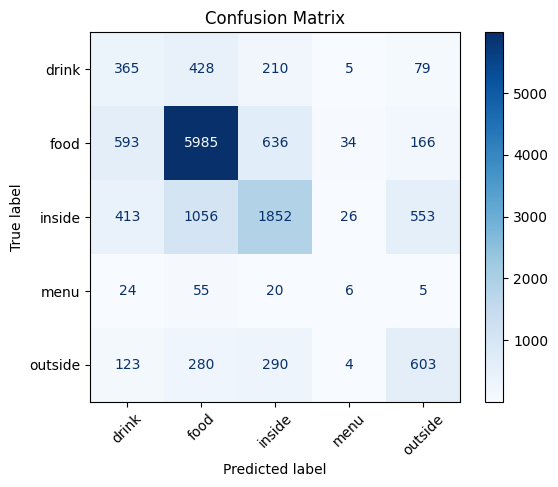

Macro-Averaged AUC: 0.6575


In [14]:
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Flatten image tensors
X_train = train_images.view(len(train_images), -1)
X_test = test_images.view(len(test_images), -1)

# Convert to numpy
X_train_np = X_train.numpy()
y_train_np = train_labels.numpy()
X_test_np = X_test.numpy()
y_test_np = test_labels.numpy()

# kNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_np, y_train_np)

# Predict
y_pred = knn.predict(X_test_np)

# Accuracy
accuracy = accuracy_score(y_test_np, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test_np, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# AUC Score
n_classes = len(train_dataset.classes)
y_test_bin = label_binarize(y_test_np, classes=list(range(n_classes)))
y_pred_bin = label_binarize(y_pred, classes=list(range(n_classes)))

auc_score = roc_auc_score(y_test_bin, y_pred_bin, average='macro')
print(f"Macro-Averaged AUC: {auc_score:.4f}")
